In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("Advertising.csv")

In [3]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


# Exploratory Data Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 500x500 with 0 Axes>

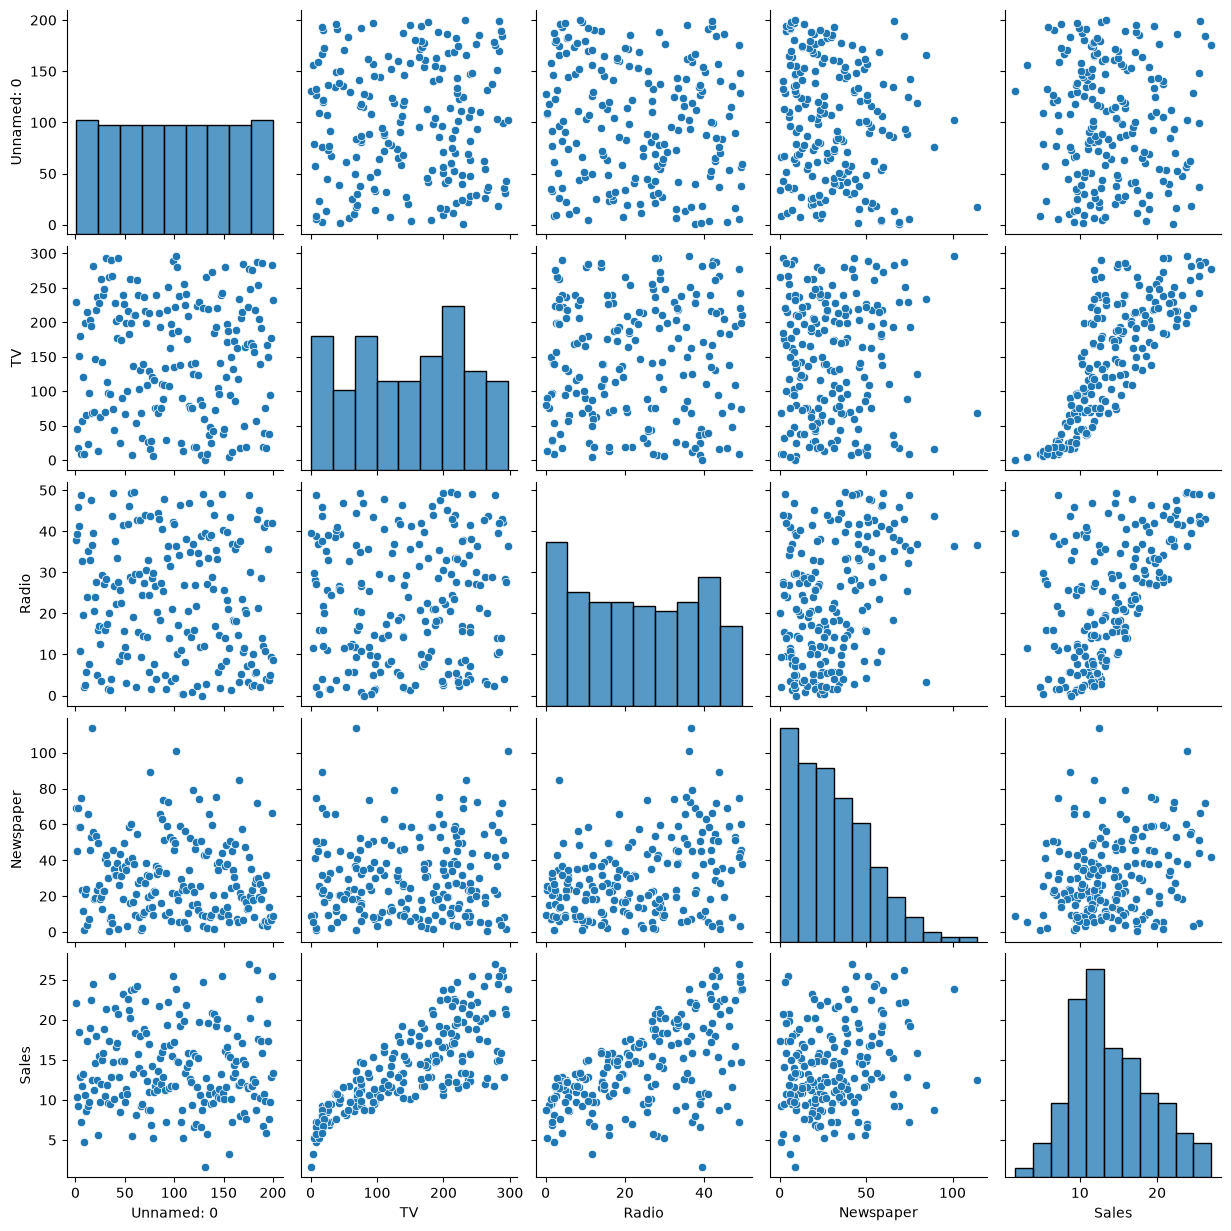

In [6]:
plt.figure(figsize=(5,5))
plt.tight_layout()
sns.pairplot(data)
plt.show

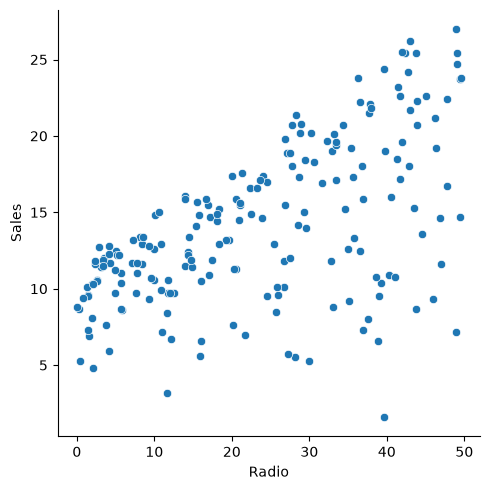

In [7]:
sns.relplot(x='Radio',y='Sales',data=data)

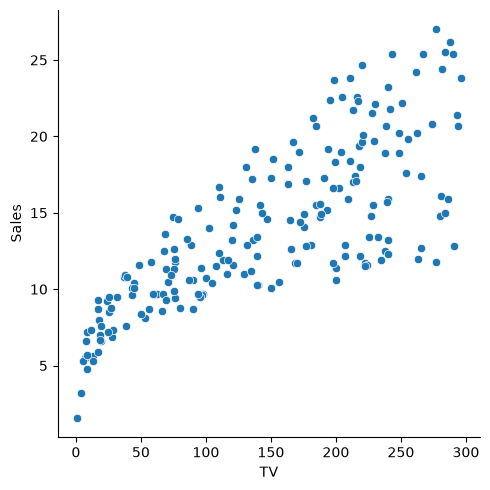

In [8]:
sns.relplot(x='TV',y='Sales',data=data)

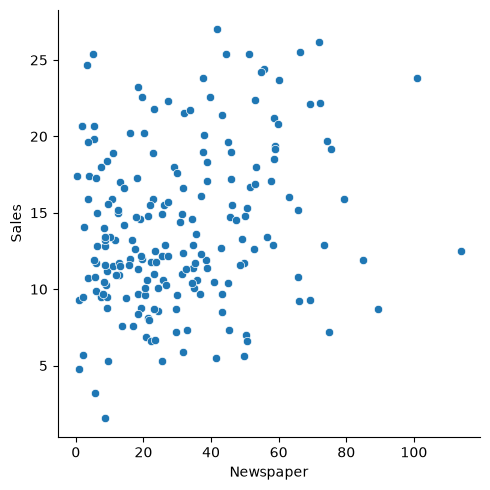

In [9]:
sns.relplot(x='Newspaper',y='Sales',data=data)

In [10]:
data.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


<Axes: >

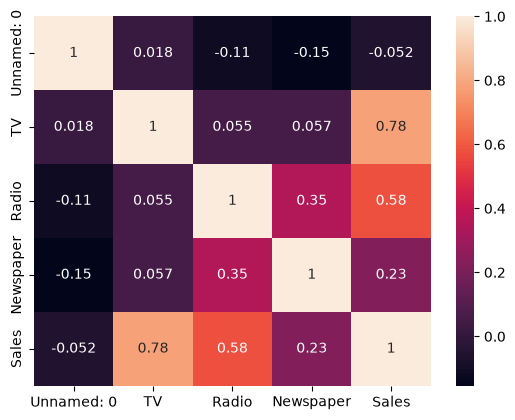

In [11]:
sns.heatmap(data.corr(),annot=True)

<Axes: ylabel='TV'>

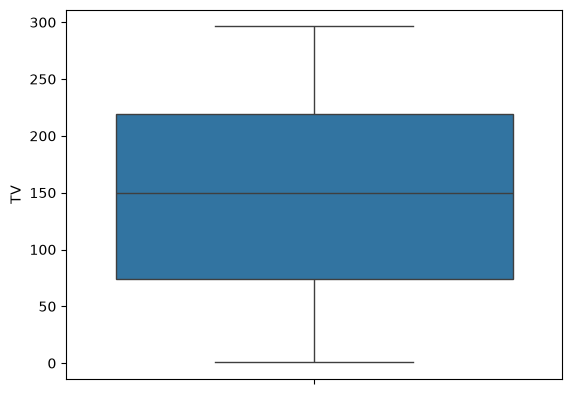

In [12]:
sns.boxplot(data.TV)

<Axes: ylabel='Radio'>

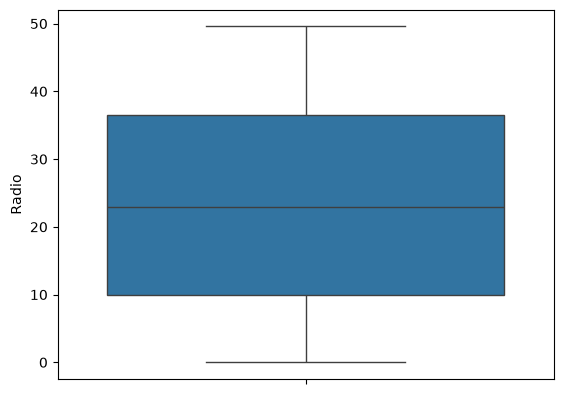

In [13]:
sns.boxplot(data.Radio)

<Axes: ylabel='Newspaper'>

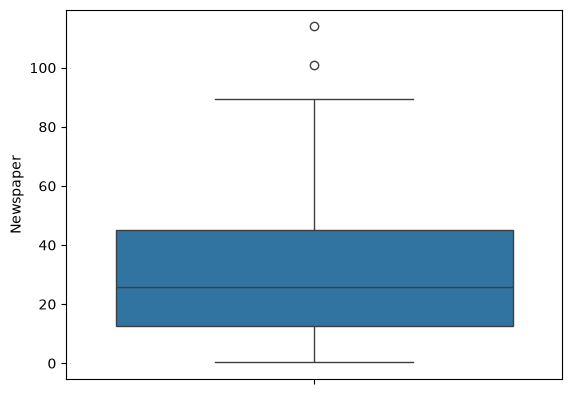

In [14]:
sns.boxplot(data.Newspaper)

# Model creation

In [15]:
X = data.drop('Sales',axis=1)
Y = data.Sales

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [17]:
print(len(X),len(x_train),len(x_test))

200 160 40


In [18]:
import sklearn
sklearn.set_config(print_changed_only=False)

In [19]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(x_train,y_train)
LR

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0. ,0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Unnamed: 0','TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.907
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [20]:
LR.coef_

array([0.00064359, 0.04471835, 0.18925118, 0.00304577])

In [21]:
LR.intercept_

np.float64(2.9065270863618053)

In [22]:
y_pred = LR.predict(x_test)

In [23]:
y_pred

array([16.41227699, 20.84319293, 21.51186915, 10.65309994, 22.12405753,
       13.12383506, 21.03748883,  7.50385439, 13.64787029, 15.12040886,
        9.02055551,  6.70666642, 14.40155146,  8.88609041,  9.74353333,
       12.21551975,  8.71370868, 16.2941451 , 10.26802337, 18.80498245,
       19.58864662, 13.22318303, 12.3647867 , 21.31473607,  7.79734749,
        5.78189965, 20.74934811, 11.95476656,  9.199109  ,  8.52178704,
       12.40431294,  9.94865202, 21.36880272, 12.25374832, 18.29943527,
       20.13347356, 14.07464638, 20.88594679, 11.05214979,  4.55168744])

In [24]:
df = pd.DataFrame()
df['Test'] = y_test
df['Predict'] = y_pred
df['Error'] = df.Test-df.Predict

In [25]:
df

,Test,Predict,Error
95,16.9,16.412277,0.487723
15,22.4,20.843193,1.556807
30,21.4,21.511869,-0.111869
158,7.3,10.653100,-3.353100
128,24.7,22.124058,2.575942
115,12.6,13.123835,-0.523835
69,22.3,21.037489,1.262511
170,8.4,7.503854,0.896146
174,11.5,13.647870,-2.147870
45,14.9,15.120409,-0.220409


In [26]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [27]:
print('Mean Squared Error:',mean_squared_error(y_test,y_pred),'\nMean_Absolute_Error:',mean_absolute_error(y_test,y_pred),
      '\nR2 Score:',r2_score(y_test,y_pred),'\nRoot Mean Square Error(RMSE) :',mean_squared_error(y_test,y_pred)**0.5)

Mean Squared Error: 3.1990044685889005 
Mean_Absolute_Error: 1.4650601050102925 
R2 Score: 0.8986489151417081 
Root Mean Square Error(RMSE) : 1.7885761008659655


In [28]:
r2 = r2_score(y_test,y_pred)
r2

0.8986489151417081

In [29]:
adj_r2 = 1-((1-r2)*(40-1)/(40-3-1))
adj_r2

0.8902029914035171